In [1]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU — enable T4!")
print("CUDA:", torch.version.cuda)

GPU: Tesla T4
CUDA: 12.8


In [2]:
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow tqdm opencv-python-headless


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/disease_data"

for folder in ["bone_fracture", "knee", "dental"]:
    path = os.path.join(BASE, folder)
    print(f"  {folder}: {'✅' if os.path.exists(path) else '❌ NOT FOUND'}")



Mounted at /content/drive
  bone_fracture: ✅
  knee: ✅
  dental: ✅


In [4]:
import os, random, shutil, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
class SimpleDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples=[]; self.transform=transform
        self.classes=sorted([d for d in os.listdir(root)
                             if os.path.isdir(os.path.join(root,d))])
        self.class_to_idx={c:i for i,c in enumerate(self.classes)}
        for cls in self.classes:
            d=os.path.join(root,cls)
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((os.path.join(d,f),
                                         self.class_to_idx[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p,l=self.samples[idx]
        try: img=Image.open(p).convert('RGB')
        except: img=Image.new('RGB',(224,224),0)
        if self.transform: img=self.transform(img)
        return img,l

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def build_resnet(num_classes):
    m=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for n,p in m.named_parameters():
        if "layer4" not in n and "fc" not in n: p.requires_grad=False
    m.fc=nn.Sequential(nn.Dropout(0.4),nn.Linear(m.fc.in_features,512),
                        nn.ReLU(),nn.Dropout(0.3),nn.Linear(512,num_classes))
    return m

def train_epoch(model,loader,criterion,optimizer):
    model.train(); tl,correct,total=0,0,0
    for imgs,labels in tqdm(loader,desc="  Train",leave=False):
        imgs,labels=imgs.to(device),labels.to(device)
        optimizer.zero_grad(); out=model(imgs)
        loss=criterion(out,labels); loss.backward(); optimizer.step()
        tl+=loss.item(); correct+=(out.argmax(1)==labels).sum().item()
        total+=labels.size(0)
    return tl/len(loader),correct/total

def val_epoch(model,loader,criterion):
    model.eval(); tl,correct,total=0,0,0
    with torch.no_grad():
        for imgs,labels in tqdm(loader,desc="  Val  ",leave=False):
            imgs,labels=imgs.to(device),labels.to(device)
            out=model(imgs); tl+=criterion(out,labels).item()
            correct+=(out.argmax(1)==labels).sum().item(); total+=labels.size(0)
    return tl/len(loader),correct/total

def train_model(model,train_loader,val_loader,criterion,epochs_p1=10,epochs_p2=5,
                save_path="/content/best.pth"):
    best_acc=0.0; history={k:[] for k in ["tl","vl","ta","va"]}
    optimizer=optim.AdamW(filter(lambda p:p.requires_grad,model.parameters()),
                          lr=1e-4,weight_decay=1e-4)
    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs_p1,eta_min=1e-6)

    print("PHASE 1 — frozen backbone")
    for epoch in range(1,epochs_p1+1):
        tl,ta=train_epoch(model,train_loader,criterion,optimizer)
        vl,va=val_epoch(model,val_loader,criterion); scheduler.step()
        for k,v in zip(history,[tl,vl,ta,va]): history[k].append(v)
        flag=""
        if va>best_acc: best_acc=va; torch.save(model.state_dict(),save_path); flag="  ← best"
        print(f"  Epoch {epoch:02d}/{epochs_p1} | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

    # Phase 2
    model.load_state_dict(torch.load(save_path))
    for p in model.parameters(): p.requires_grad=True
    opt2=optim.AdamW(model.parameters(),lr=3e-5,weight_decay=1e-4)
    sch2=optim.lr_scheduler.CosineAnnealingLR(opt2,T_max=epochs_p2,eta_min=1e-7)

    print("PHASE 2 — full fine-tuning")
    for epoch in range(1,epochs_p2+1):
        tl,ta=train_epoch(model,train_loader,criterion,opt2)
        vl,va=val_epoch(model,val_loader,criterion); sch2.step()
        for k,v in zip(history,[tl,vl,ta,va]): history[k].append(v)
        flag=""
        if va>best_acc: best_acc=va; torch.save(model.state_dict(),save_path); flag="  ← best"
        print(f"  Epoch {epoch:02d}/{epochs_p2} | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

    print(f"\nBest val accuracy: {best_acc*100:.2f}%")
    return best_acc, history

def save_to_drive(files, save_dir="/content/drive/MyDrive/medical_ai_models"):
    os.makedirs(save_dir, exist_ok=True)
    for fp in files:
        if os.path.exists(fp):
            shutil.copy2(fp, os.path.join(save_dir, os.path.basename(fp)))
            print(f"  Saved: {os.path.basename(fp)}")

print("Shared utilities ready.")


Shared utilities ready.


In [7]:
# CELL 6 - Build Bone dataset
# 4 classes from 2 datasets:
#   Normal_Bone   → bone_fracture normal images + knee 0Normal
#   Fracture      → bone_fracture fractured images
#   Osteoporosis  → knee 3Moderate + 4Severe (severe bone/joint loss)
#   Osteoarthritis→ knee 1Doubtful + 2Mild (early joint changes)
# ================================================================
BONE_BASE  = f"{BASE}/bone_fracture/BoneFractureYolo8"
KNEE_BASE  = f"{BASE}/knee/MedicalExpert-I"
BONE_OUT   = "/content/bone_combined"
BONE_CLASSES = ["Fracture", "Normal_Bone", "Osteoarthritis", "Osteoporosis"]

for cls in BONE_CLASSES:
    os.makedirs(f"{BONE_OUT}/{cls}", exist_ok=True)

print("Building Bone Disease dataset...\n")

def copy_imgs(src, dest, limit=2000, tag=""):
    if not os.path.exists(src):
        print(f"  [SKIP] {src}"); return 0
    files=[f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    files=files[:limit]
    for i,f in enumerate(tqdm(files,desc=f"  {tag}",leave=False)):
        shutil.copy2(os.path.join(src,f),
                     f"{dest}/{tag}_{i:05d}{os.path.splitext(f)[1]}")
    return len(files)

# Normal bone — from bone dataset train/valid images (not fractured)
# Note: YOLO dataset mixes fractured/normal in same images folder
# We'll take all images and the model learns from visual patterns
n1 = copy_imgs(f"{BONE_BASE}/train/images", f"{BONE_OUT}/Normal_Bone", 1500, "bone_normal_train")
n2 = copy_imgs(f"{BONE_BASE}/valid/images", f"{BONE_OUT}/Normal_Bone",  500, "bone_normal_valid")
n3 = copy_imgs(f"{KNEE_BASE}/0Normal",      f"{BONE_OUT}/Normal_Bone", 1000, "knee_normal")
print(f"  Normal_Bone: {n1+n2+n3}")

# Fracture — from second YOLO dataset (v4)
BONE_V4 = f"{BASE}/bone_fracture/bone fracture detection.v4-v4.yolov8"
f1 = copy_imgs(f"{BONE_V4}/train/images",   f"{BONE_OUT}/Fracture", 2000, "fracture_train")
f2 = copy_imgs(f"{BONE_V4}/valid/images",   f"{BONE_OUT}/Fracture",  500, "fracture_valid")
# Also use test images
f3 = copy_imgs(f"{BONE_BASE}/test/images",  f"{BONE_OUT}/Fracture",  500, "fracture_test")
print(f"  Fracture: {f1+f2+f3}")

# Osteoporosis — severe knee grades (significant bone density/structure loss)
o1 = copy_imgs(f"{KNEE_BASE}/3Moderate", f"{BONE_OUT}/Osteoporosis", 1000, "osteo_moderate")
o2 = copy_imgs(f"{KNEE_BASE}/4Severe",   f"{BONE_OUT}/Osteoporosis", 1000, "osteo_severe")
print(f"  Osteoporosis: {o1+o2}")

# Osteoarthritis — early/mild joint changes
a1 = copy_imgs(f"{KNEE_BASE}/1Doubtful", f"{BONE_OUT}/Osteoarthritis", 1000, "oa_doubtful")
a2 = copy_imgs(f"{KNEE_BASE}/2Mild",     f"{BONE_OUT}/Osteoarthritis", 1000, "oa_mild")
print(f"  Osteoarthritis: {a1+a2}")

print(f"\nFinal bone dataset:")
for cls in BONE_CLASSES:
    print(f"  {cls:20s}: {len(os.listdir(f'{BONE_OUT}/{cls}'))}")

Building Bone Disease dataset...



  Normal_Bone: 2362


  Fracture: 2517


  Osteoporosis: 427


  Osteoarthritis: 709

Final bone dataset:
  Fracture            : 2517
  Normal_Bone         : 2362
  Osteoarthritis      : 709
  Osteoporosis        : 427


In [8]:
bone_ds     = SimpleDataset(BONE_OUT, transform=train_tf)
bone_classes= bone_ds.classes
bone_counts = Counter([bone_ds.samples[i][1] for i in range(len(bone_ds))])
val_size    = int(0.15*len(bone_ds))
tr_bone, vl_bone = torch.utils.data.random_split(
    bone_ds,[len(bone_ds)-val_size,val_size],
    generator=torch.Generator().manual_seed(42))
vl_bone.dataset = SimpleDataset(BONE_OUT, transform=val_tf)

tr_bone_loader = DataLoader(tr_bone,batch_size=32,shuffle=True, num_workers=2,pin_memory=True)
vl_bone_loader = DataLoader(vl_bone,batch_size=32,shuffle=False,num_workers=2,pin_memory=True)

bone_weights = torch.tensor(
    [sum(bone_counts.values())/(len(bone_classes)*bone_counts[i])
     for i in range(len(bone_classes))],dtype=torch.float).to(device)
bone_criterion = nn.CrossEntropyLoss(weight=bone_weights)

bone_model = build_resnet(len(bone_classes)).to(device)

print(f"="*55)
print(f"BONE DISEASE MODEL — {len(bone_classes)} classes")
print(f"Classes: {bone_classes}")
print(f"Train: {len(tr_bone)} | Val: {len(vl_bone)}")
print(f"="*55)

best_bone, bone_history = train_model(
    bone_model, tr_bone_loader, vl_bone_loader,
    bone_criterion, save_path="/content/bone_best.pth")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


BONE DISEASE MODEL — 4 classes
Classes: ['Fracture', 'Normal_Bone', 'Osteoarthritis', 'Osteoporosis']
Train: 5113 | Val: 902
PHASE 1 — frozen backbone


  Epoch 01/10 | Train 52.22% | Val 59.65%  ← best


  Epoch 02/10 | Train 58.28% | Val 59.42%


...

  Epoch 01/5 | Train 63.23% | Val 61.86%


  Epoch 02/5 | Train 64.05% | Val 61.75%


  Epoch 03/5 | Train 63.76% | Val 62.86%  ← best


  Epoch 04/5 | Train 64.62% | Val 60.98%


  Epoch 05/5 | Train 65.50% | Val 61.20%

Best val accuracy: 62.86%


Eval: 100%|██████████| 29/29 [00:07<00:00,  4.02it/s]


                precision    recall  f1-score   support

      Fracture       0.56      0.93      0.70       378
   Normal_Bone       0.65      0.19      0.30       359
Osteoarthritis       0.83      0.85      0.84       105
  Osteoporosis       0.92      0.93      0.93        60

      accuracy                           0.63       902
     macro avg       0.74      0.73      0.69       902
  weighted avg       0.65      0.63      0.57       902



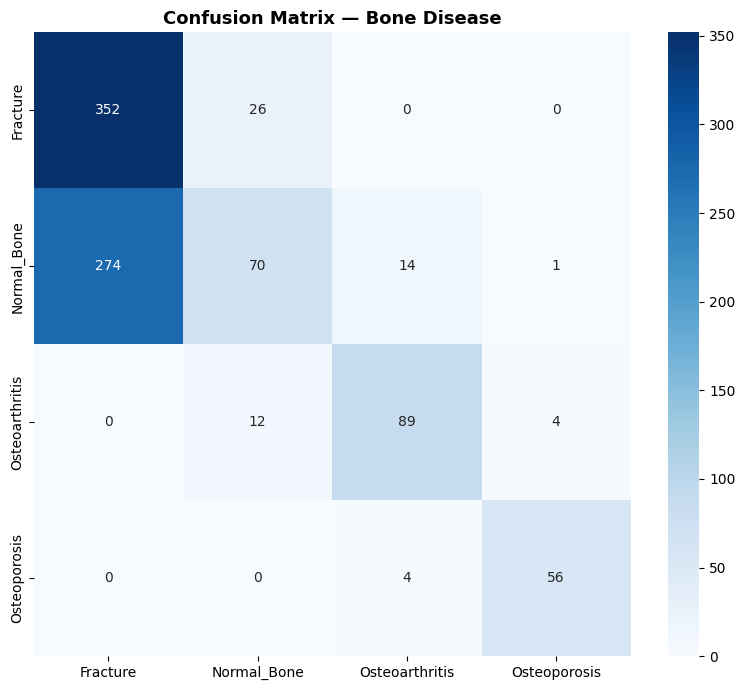

  Saved: bone_model.pth
  Saved: bone_metadata.json
  Saved: bone_cm.png
✅ Bone model done — 62.86%


In [9]:
bone_model.load_state_dict(torch.load("/content/bone_best.pth"))
bone_model.eval()
all_p,all_l=[],[]
with torch.no_grad():
    for imgs,labels in tqdm(vl_bone_loader,desc="Eval"):
        all_p.extend(bone_model(imgs.to(device)).argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())

print(classification_report(all_l,all_p,target_names=bone_classes))
cm=confusion_matrix(all_l,all_p)
fig,ax=plt.subplots(figsize=(8,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=bone_classes,yticklabels=bone_classes,ax=ax)
ax.set_title("Confusion Matrix — Bone Disease",fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig("/content/bone_cm.png",dpi=120); plt.show()

torch.save(bone_model.state_dict(),"/content/bone_model.pth")
bone_metadata={
    "model_name":"ResNet50 Bone Disease Detector",
    "num_classes":len(bone_classes),"classes":bone_classes,
    "class_to_idx":{c:i for i,c in enumerate(bone_classes)},
    "input_size":[224,224],
    "normalize_mean":[0.485,0.456,0.406],
    "normalize_std":[0.229,0.224,0.225],
    "best_val_accuracy":round(best_bone*100,2),
    "scan_type":"X-ray",
    "disease_info":{
        "Normal_Bone":{
            "description":"Normal healthy bone structure with no abnormalities detected.",
            "symptoms":["No symptoms"],"treatment":"No treatment required",
            "risk":"None","emergency":False
        },
        "Fracture":{
            "description":"A break or crack in a bone caused by trauma, stress, or disease.",
            "symptoms":["Severe pain","Swelling","Bruising","Deformity","Inability to move"],
            "treatment":"Immobilization (cast/splint), surgery for complex fractures, physiotherapy",
            "risk":"Moderate-High","emergency":True
        },
        "Osteoporosis":{
            "description":"Reduced bone density making bones weak and more prone to fractures.",
            "symptoms":["Back pain","Loss of height","Stooped posture","Fragility fractures"],
            "treatment":"Calcium+Vitamin D, bisphosphonates (alendronate), lifestyle changes, weight-bearing exercise",
            "risk":"Moderate","emergency":False
        },
        "Osteoarthritis":{
            "description":"Degenerative joint disease causing cartilage breakdown and bone changes.",
            "symptoms":["Joint pain","Stiffness","Swelling","Reduced range of motion","Grating sensation"],
            "treatment":"Pain management (NSAIDs), physiotherapy, weight loss, joint replacement if severe",
            "risk":"Moderate","emergency":False
        }
    }
}
with open("/content/bone_metadata.json","w") as f: json.dump(bone_metadata,f,indent=2)
save_to_drive(["/content/bone_model.pth","/content/bone_metadata.json","/content/bone_cm.png"])
print(f"✅ Bone model done — {best_bone*100:.2f}%")



In [10]:
KNEE_DATA_BASE = f"{BASE}/knee/MedicalExpert-I"
KNEE_OUT       = "/content/knee_combined"
KNEE_CLASSES   = ["Normal","Doubtful","Mild","Moderate","Severe"]

# Folder names → class names
KNEE_FOLDER_MAP = {
    "0Normal"   : "Normal",
    "1Doubtful" : "Doubtful",
    "2Mild"     : "Mild",
    "3Moderate" : "Moderate",
    "4Severe"   : "Severe"
}

for cls in KNEE_CLASSES:
    os.makedirs(f"{KNEE_OUT}/{cls}", exist_ok=True)

# Also add MedicalExpert-II for more data
KNEE_EXPERT2 = f"{BASE}/knee/MedicalExpert-II"

print("Building Knee Osteoarthritis dataset...\n")
total_knee = 0
for folder, cls in KNEE_FOLDER_MAP.items():
    # Expert I
    src1 = os.path.join(KNEE_DATA_BASE, folder)
    n = copy_imgs(src1, f"{KNEE_OUT}/{cls}", 2000, f"e1_{folder}")
    # Expert II (extra data)
    src2 = os.path.join(KNEE_EXPERT2, folder)
    n2 = copy_imgs(src2, f"{KNEE_OUT}/{cls}", 1000, f"e2_{folder}")
    total_knee += n + n2
    print(f"  {cls}: {n+n2}")

print(f"\nTotal knee images: {total_knee}")



Building Knee Osteoarthritis dataset...



  Normal: 1017


  Doubtful: 965


  Mild: 464


  Moderate: 442


  Severe: 412

Total knee images: 3300


In [11]:
knee_ds     = SimpleDataset(KNEE_OUT, transform=train_tf)
knee_classes= knee_ds.classes
knee_counts = Counter([knee_ds.samples[i][1] for i in range(len(knee_ds))])
val_size    = int(0.15*len(knee_ds))
tr_knee,vl_knee = torch.utils.data.random_split(
    knee_ds,[len(knee_ds)-val_size,val_size],
    generator=torch.Generator().manual_seed(42))
vl_knee.dataset = SimpleDataset(KNEE_OUT, transform=val_tf)

tr_knee_loader = DataLoader(tr_knee,batch_size=32,shuffle=True, num_workers=2,pin_memory=True)
vl_knee_loader = DataLoader(vl_knee,batch_size=32,shuffle=False,num_workers=2,pin_memory=True)

knee_weights = torch.tensor(
    [sum(knee_counts.values())/(len(knee_classes)*knee_counts[i])
     for i in range(len(knee_classes))],dtype=torch.float).to(device)
knee_criterion = nn.CrossEntropyLoss(weight=knee_weights)
knee_model     = build_resnet(len(knee_classes)).to(device)

print(f"="*55)
print(f"KNEE OSTEOARTHRITIS MODEL — {len(knee_classes)} classes")
print(f"Classes: {knee_classes}")
print(f"Train: {len(tr_knee)} | Val: {len(vl_knee)}")
print(f"="*55)

best_knee, knee_history = train_model(
    knee_model, tr_knee_loader, vl_knee_loader,
    knee_criterion, save_path="/content/knee_best.pth")

KNEE OSTEOARTHRITIS MODEL — 5 classes
Classes: ['Doubtful', 'Mild', 'Moderate', 'Normal', 'Severe']
Train: 2805 | Val: 495
PHASE 1 — frozen backbone


  Epoch 01/10 | Train 39.43% | Val 61.21%  ← best


  Epoch 02/10 | Train 61.50% | Val 68.08%  ← best


  Epoch 03/10 | Train 70.37% | Val 76.36%  ← best


  Epoch 04/10 | Train 74.15% | Val 76.16%


...

  Epoch 01/5 | Train 82.03% | Val 86.06%  ← best


  Epoch 02/5 | Train 84.63% | Val 84.04%


  Epoch 03/5 | Train 85.78% | Val 85.86%


  Epoch 04/5 | Train 86.35% | Val 87.47%  ← best


  Epoch 05/5 | Train 87.70% | Val 86.87%

Best val accuracy: 87.47%


Eval: 100%|██████████| 16/16 [00:03<00:00,  4.58it/s]


              precision    recall  f1-score   support

    Doubtful       0.89      0.87      0.88       165
        Mild       0.77      0.80      0.79        71
    Moderate       0.88      0.80      0.84        56
      Normal       0.88      0.91      0.89       149
      Severe       0.96      0.96      0.96        54

    accuracy                           0.87       495
   macro avg       0.88      0.87      0.87       495
weighted avg       0.88      0.87      0.87       495



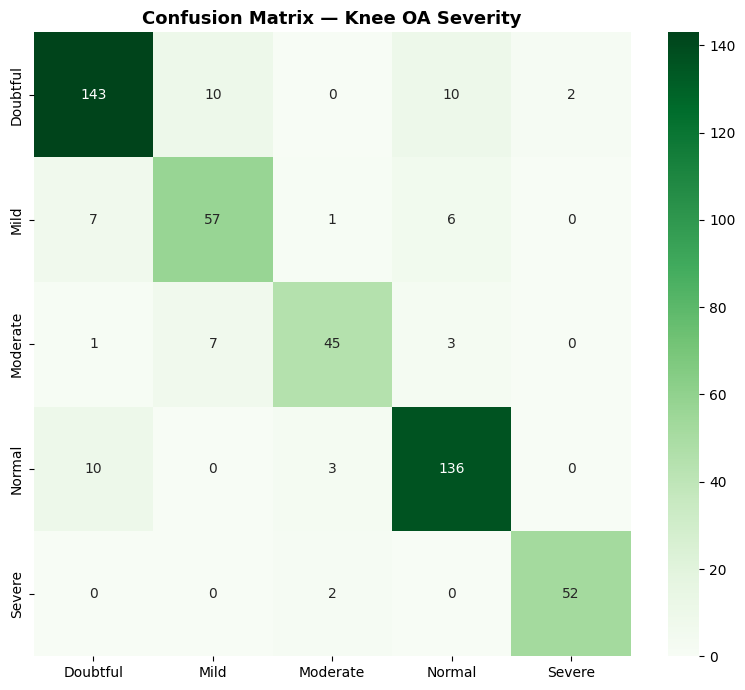

  Saved: knee_model.pth
  Saved: knee_metadata.json
  Saved: knee_cm.png
✅ Knee model done — 87.47%


In [12]:
knee_model.load_state_dict(torch.load("/content/knee_best.pth"))
knee_model.eval()
all_p,all_l=[],[]
with torch.no_grad():
    for imgs,labels in tqdm(vl_knee_loader,desc="Eval"):
        all_p.extend(knee_model(imgs.to(device)).argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())

print(classification_report(all_l,all_p,target_names=knee_classes))
cm=confusion_matrix(all_l,all_p)
fig,ax=plt.subplots(figsize=(8,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens',
            xticklabels=knee_classes,yticklabels=knee_classes,ax=ax)
ax.set_title("Confusion Matrix — Knee OA Severity",fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig("/content/knee_cm.png",dpi=120); plt.show()

torch.save(knee_model.state_dict(),"/content/knee_model.pth")
knee_metadata={
    "model_name":"ResNet50 Knee OA Severity",
    "num_classes":len(knee_classes),"classes":knee_classes,
    "class_to_idx":{c:i for i,c in enumerate(knee_classes)},
    "input_size":[224,224],
    "normalize_mean":[0.485,0.456,0.406],
    "normalize_std":[0.229,0.224,0.225],
    "best_val_accuracy":round(best_knee*100,2),
    "scan_type":"Knee X-ray",
    "grading_scale":"Kellgren-Lawrence grading scale (0-4)",
    "disease_info":{
        "Normal":{
            "description":"No signs of osteoarthritis. Healthy knee joint with normal joint space.",
            "kl_grade":"Grade 0","symptoms":["No symptoms"],
            "treatment":"Preventive care, maintain healthy weight","risk":"None"
        },
        "Doubtful":{
            "description":"Doubtful narrowing of joint space, possible osteophytic lipping.",
            "kl_grade":"Grade 1","symptoms":["Occasional mild knee pain","Slight stiffness"],
            "treatment":"Exercise, weight management, anti-inflammatory if needed","risk":"Low"
        },
        "Mild":{
            "description":"Definite osteophytes and possible narrowing of joint space.",
            "kl_grade":"Grade 2","symptoms":["Knee pain after activity","Morning stiffness <30 min","Mild swelling"],
            "treatment":"NSAIDs, physiotherapy, knee exercises, weight loss","risk":"Low-Moderate"
        },
        "Moderate":{
            "description":"Moderate multiple osteophytes, definite narrowing, some sclerosis, possible bone deformity.",
            "kl_grade":"Grade 3","symptoms":["Frequent pain","Significant stiffness","Swelling","Reduced mobility"],
            "treatment":"Strong NSAIDs, cortisone injections, hyaluronic acid, physiotherapy","risk":"Moderate"
        },
        "Severe":{
            "description":"Large osteophytes, marked narrowing, severe sclerosis, definite bone deformity.",
            "kl_grade":"Grade 4","symptoms":["Constant severe pain","Very limited mobility","Significant deformity","Bone-on-bone contact"],
            "treatment":"Total knee replacement (TKR) surgery is usually indicated","risk":"High"
        }
    }
}
with open("/content/knee_metadata.json","w") as f: json.dump(knee_metadata,f,indent=2)
save_to_drive(["/content/knee_model.pth","/content/knee_metadata.json","/content/knee_cm.png"])
print(f"✅ Knee model done — {best_knee*100:.2f}%")



In [ ]:
DENTAL_BASE    = f"{BASE}/dental"
DENTAL_OUT     = "/content/dental_combined"
DENTAL_CLASSES = ["Calculus","Caries","Gingivitis",
                  "Mouth_Ulcer","Tooth_Discoloration","Hypodontia"]

for cls in DENTAL_CLASSES:
    os.makedirs(f"{DENTAL_OUT}/{cls}", exist_ok=True)

# Map your exact folder paths → class names
DENTAL_SOURCES = {
    "Calculus": [
        os.path.join(DENTAL_BASE, "Calculus", "Calculus"),
    ],
    "Caries": [
        os.path.join(DENTAL_BASE, "Data caries", "Data caries",
                     "caries orignal data set", "done"),
        os.path.join(DENTAL_BASE, "Data caries", "Data caries",
                     "caries augmented data set"),
    ],
    "Gingivitis": [
        os.path.join(DENTAL_BASE, "Gingivitis", "Gingivitis"),
    ],
    "Mouth_Ulcer": [
        os.path.join(DENTAL_BASE, "Mouth Ulcer", "Mouth Ulcer",
                     "ulcer original dataset", "ulcer original dataset"),
        os.path.join(DENTAL_BASE, "Mouth Ulcer", "Mouth Ulcer",
                     "Mouth_Ulcer_augmented_DataSet"),
    ],
    "Tooth_Discoloration": [
        os.path.join(DENTAL_BASE, "Tooth Discoloration", "Tooth Discoloration",
                     "tooth discoloration original dataset",
                     "tooth discoloration original dataset"),
        os.path.join(DENTAL_BASE, "Tooth Discoloration", "Tooth Discoloration",
                     "Tooth_discoloration_augmented_dataser"),
    ],
    "Hypodontia": [
        os.path.join(DENTAL_BASE, "hypodontia", "hypodontia"),
    ],
}

print("Building Dental Disease dataset...\n")
total_dental = 0
for cls, src_list in DENTAL_SOURCES.items():
    cls_count = 0
    for src in src_list:
        if not os.path.exists(src):
            print(f"  [SKIP] {src}"); continue
        # Get images (may be nested one level)
        files = [f for f in os.listdir(src)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
        # Also check one level deeper
        if len(files) == 0:
            for sub in os.listdir(src):
                sub_path = os.path.join(src, sub)
                if os.path.isdir(sub_path):
                    sub_files = [f for f in os.listdir(sub_path)
                                 if f.lower().endswith(('.jpg','.jpeg','.png'))]
                    for i, f in enumerate(tqdm(sub_files[:500],
                                               desc=f"  {cls}/{sub}",leave=False)):
                        dest = f"{DENTAL_OUT}/{cls}/{cls}_{sub}_{i:05d}{os.path.splitext(f)[1]}"
                        shutil.copy2(os.path.join(sub_path, f), dest)
                    cls_count += len(sub_files[:500])
        else:
            tag = src.split(os.sep)[-1].replace(" ","_")
            for i,f in enumerate(tqdm(files[:2000],
                                       desc=f"  {cls}",leave=False)):
                dest = f"{DENTAL_OUT}/{cls}/{cls}_{tag}_{i:05d}{os.path.splitext(f)[1]}"
                shutil.copy2(os.path.join(src, f), dest)
            cls_count += len(files[:2000])
    total_dental += cls_count
    print(f"  {cls}: {cls_count}")

print(f"\nTotal dental images: {total_dental}")
print("Final breakdown:")
for cls in DENTAL_CLASSES:
    p = f"{DENTAL_OUT}/{cls}"
    if os.path.exists(p):
        print(f"  {cls:25s}: {len(os.listdir(p))}")



Building Dental Disease dataset...



  Calculus: 1296


  Caries: 719


  Gingivitis: 2000


  Mouth_Ulcer: 765


  Tooth_Discoloration: 683


  Hypodontia:   1%|          | 13/1251 [00:03<06:10,  3.34it/s]

In [ ]:
dental_ds     = SimpleDataset(DENTAL_OUT, transform=train_tf)
dental_classes= dental_ds.classes
dental_counts = Counter([dental_ds.samples[i][1] for i in range(len(dental_ds))])
val_size      = int(0.15*len(dental_ds))
tr_dental,vl_dental = torch.utils.data.random_split(
    dental_ds,[len(dental_ds)-val_size,val_size],
    generator=torch.Generator().manual_seed(42))
vl_dental.dataset = SimpleDataset(DENTAL_OUT, transform=val_tf)

tr_dental_loader = DataLoader(tr_dental,batch_size=32,shuffle=True, num_workers=2,pin_memory=True)
vl_dental_loader = DataLoader(vl_dental,batch_size=32,shuffle=False,num_workers=2,pin_memory=True)

dental_weights = torch.tensor(
    [sum(dental_counts.values())/(len(dental_classes)*dental_counts[i])
     for i in range(len(dental_classes))],dtype=torch.float).to(device)
dental_criterion = nn.CrossEntropyLoss(weight=dental_weights)
dental_model     = build_resnet(len(dental_classes)).to(device)

print(f"="*55)
print(f"DENTAL DISEASE MODEL — {len(dental_classes)} classes")
print(f"Classes: {dental_classes}")
print(f"Train: {len(tr_dental)} | Val: {len(vl_dental)}")
print(f"="*55)

best_dental, dental_history = train_model(
    dental_model, tr_dental_loader, vl_dental_loader,
    dental_criterion, save_path="/content/dental_best.pth")


In [ ]:
dental_model.load_state_dict(torch.load("/content/dental_best.pth"))
dental_model.eval()
all_p,all_l=[],[]
with torch.no_grad():
    for imgs,labels in tqdm(vl_dental_loader,desc="Eval"):
        all_p.extend(dental_model(imgs.to(device)).argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())

print(classification_report(all_l,all_p,target_names=dental_classes))
cm=confusion_matrix(all_l,all_p)
fig,ax=plt.subplots(figsize=(9,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges',
            xticklabels=dental_classes,yticklabels=dental_classes,ax=ax)
ax.set_title("Confusion Matrix — Dental Disease",fontsize=13,fontweight='bold')
plt.xticks(rotation=25); plt.tight_layout()
plt.savefig("/content/dental_cm.png",dpi=120); plt.show()

torch.save(dental_model.state_dict(),"/content/dental_model.pth")
dental_metadata={
    "model_name":"ResNet50 Dental Disease Detector",
    "num_classes":len(dental_classes),"classes":dental_classes,
    "class_to_idx":{c:i for i,c in enumerate(dental_classes)},
    "input_size":[224,224],
    "normalize_mean":[0.485,0.456,0.406],
    "normalize_std":[0.229,0.224,0.225],
    "best_val_accuracy":round(best_dental*100,2),
    "scan_type":"Dental Photo / Intraoral Camera",
    "disease_info":{
        "Calculus":{
            "description":"Hardened dental plaque (tartar) on teeth surface, especially near gumline.",
            "symptoms":["Yellow/brown deposits on teeth","Bad breath","Gum irritation"],
            "treatment":"Professional dental scaling and polishing every 6 months",
            "risk":"Low-Moderate","emergency":False
        },
        "Caries":{
            "description":"Tooth decay caused by bacterial acid erosion of tooth enamel.",
            "symptoms":["Toothache","Sensitivity to hot/cold","Visible holes or pits","Dark spots"],
            "treatment":"Dental filling, crown for large cavities, root canal if pulp involved",
            "risk":"Moderate","emergency":False
        },
        "Gingivitis":{
            "description":"Inflammation of the gums, the earliest stage of gum disease.",
            "symptoms":["Red swollen gums","Bleeding when brushing","Bad breath","Tender gums"],
            "treatment":"Professional cleaning, improved oral hygiene, antibacterial mouthwash",
            "risk":"Low","emergency":False
        },
        "Mouth_Ulcer":{
            "description":"Painful sores on the inner lining of the mouth (aphthous ulcers).",
            "symptoms":["Painful round/oval sores","White or yellow center","Red border","Difficulty eating"],
            "treatment":"Topical corticosteroids, antiseptic mouthwash, vitamin B12 if deficient",
            "risk":"Low","emergency":False
        },
        "Tooth_Discoloration":{
            "description":"Changes in tooth color from intrinsic (internal) or extrinsic (surface) causes.",
            "symptoms":["Yellow/brown/grey tooth color","Staining on tooth surface"],
            "treatment":"Professional whitening, veneers, or crowns depending on cause",
            "risk":"Low (cosmetic)","emergency":False
        },
        "Hypodontia":{
            "description":"Congenital condition with one or more missing permanent teeth.",
            "symptoms":["Missing teeth","Gaps in smile","Retained baby teeth","Spacing issues"],
            "treatment":"Dental implants, bridges, partial dentures, or orthodontic space closure",
            "risk":"Low","emergency":False
        }
    }
}
with open("/content/dental_metadata.json","w") as f: json.dump(dental_metadata,f,indent=2)
save_to_drive(["/content/dental_model.pth","/content/dental_metadata.json",
               "/content/dental_cm.png"])
print(f"✅ Dental model done — {best_dental*100:.2f}%")



In [ ]:
print("\n" + "="*55)
print("🎉 ALL 3 MODELS TRAINED AND SAVED TO DRIVE!")
print("="*55)
print(f"  bone_model.pth    — {best_bone*100:.2f}%  ({len(bone_classes)} classes)")
print(f"  knee_model.pth    — {best_knee*100:.2f}%  ({len(knee_classes)} classes)")
print(f"  dental_model.pth  — {best_dental*100:.2f}%  ({len(dental_classes)} classes)")
print(f"\nAll saved to: Drive → medical_ai_models/")
print(f"Download and put in: project/backend/model/")